# Catastrophic Forgetting in Neural Networks

When a neural network is trained **sequentially** on multiple tasks, it tends
to *forget* earlier tasks as it learns new ones. This phenomenon is called
**catastrophic forgetting** and is the central challenge that continual
learning methods (EWC, SI, Knowledge Distillation, ...) try to solve.

## What we will do

1. Split MNIST into two tasks: **Task A** (digits 0-4) and **Task B** (digits 5-9).
2. Train a small CNN on Task A until it performs well.
3. Continue training the **same model** on Task B.
4. Re-evaluate on Task A and observe the accuracy drop.
5. Visualise the loss landscape and training trajectory to understand *why* it happens.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from cl import (
    SimpleCNN,
    evaluate,
    get_device,
    get_mnist_split,
    train_and_log,
    compute_loss_landscape,
    plot_accuracy_timeline,
    plot_loss_landscape,
    plot_loss_timeline,
    plot_trajectory_overlay,
)

device = get_device()
print(f"Using device: {device}")

Using device: cuda


### Configuration

Feel free to lower `EPOCHS_A` / `EPOCHS_B` (e.g. to 10) for a faster run if you are on CPU.

In [2]:
EPOCHS_A = 200   # epochs for Task A
EPOCHS_B = 200   # epochs for Task B
BATCH_SIZE = 128

## 2. Load data

We split MNIST into two non-overlapping groups so the model never sees both tasks at the same time.

In [3]:
trainA = DataLoader(get_mnist_split([0, 1, 2, 3, 4], train=True),
                    batch_size=BATCH_SIZE, shuffle=True)
testA  = DataLoader(get_mnist_split([0, 1, 2, 3, 4], train=False),
                    batch_size=256)

trainB = DataLoader(get_mnist_split([5, 6, 7, 8, 9], train=True),
                    batch_size=BATCH_SIZE, shuffle=True)
testB  = DataLoader(get_mnist_split([5, 6, 7, 8, 9], train=False),
                    batch_size=256)

print(f"Task A - train: {len(trainA.dataset):,}  test: {len(testA.dataset):,}")
print(f"Task B - train: {len(trainB.dataset):,}  test: {len(testB.dataset):,}")

Task A - train: 30,596  test: 5,139
Task B - train: 29,404  test: 4,861


## 3. Create the model

A small CNN - fast to train, yet powerful enough to get >99% accuracy on each task individually.

In [4]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Train on Task A (digits 0-4)

We train the model to near-perfect accuracy on the first five digits.

In [5]:
snapshots = []
accA, lossA, _ = train_and_log(model, trainA, optimizer, criterion,
                            EPOCHS_A, snapshots=snapshots)
accA_before = evaluate(model, testA)
print(f"\nTask A test accuracy: {accA_before:.3f}")


Task A test accuracy: 0.998


### Loss landscape after Task A

The model sits in a **good minimum** for Task A - low loss in the centre of the plot.

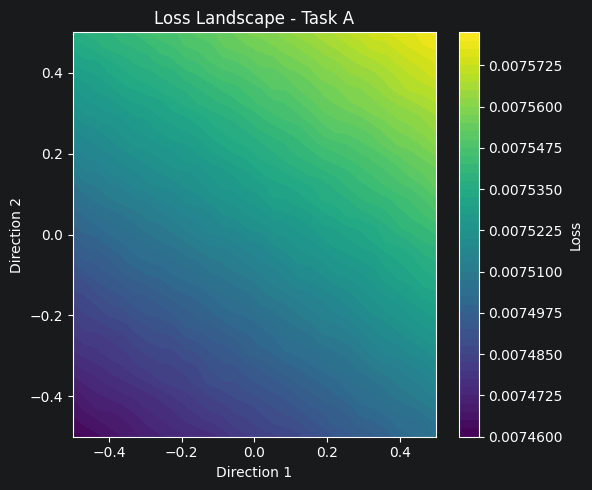

In [6]:
landscape_A = compute_loss_landscape(model, criterion, testA)
plot_loss_landscape(landscape_A, title="Loss Landscape - Task A", cmap="viridis")
plt.show()

## 5. Train on Task B (digits 5-9)

Now we continue training the **same model** on a completely different set of digits.
The optimizer keeps updating the same weights - there is no mechanism to protect what was learned for Task A.

In [7]:
accB, lossB, accA_during_B = train_and_log(model, trainB, optimizer, criterion,
                            EPOCHS_B, snapshots=snapshots,
                            eval_loader=testA)
accB_final = evaluate(model, testB)
print(f"\nTask B test accuracy: {accB_final:.3f}")



Task B test accuracy: 0.994


## 6. The forgetting - re-evaluate Task A

Let us check how much Task A accuracy has **dropped** after Task B training.

In [8]:
accA_after = evaluate(model, testA)

print(f"Task A accuracy BEFORE Task B: {accA_before:.3f}")
print(f"Task A accuracy AFTER  Task B: {accA_after:.3f}")
print(f"\nForgetting: {accA_before - accA_after:.3f}")

Task A accuracy BEFORE Task B: 0.998
Task A accuracy AFTER  Task B: 0.000

Forgetting: 0.998


### Loss landscape after Task B

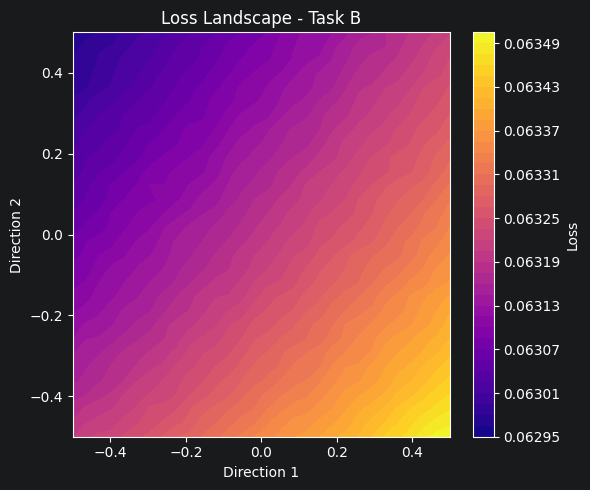

In [9]:
landscape_B = compute_loss_landscape(model, criterion, testB)
plot_loss_landscape(landscape_B, title="Loss Landscape - Task B", cmap="plasma")
plt.show()

## 7. Accuracy and loss timelines

Notice how the training accuracy curve is continuous - the model transitions
smoothly from one task to the next, **but** the old task's performance is silently destroyed.
The red **"Task A test acc (during B)"** line shows this forgetting in real time —
Task A accuracy plummets as the model trains on Task B.


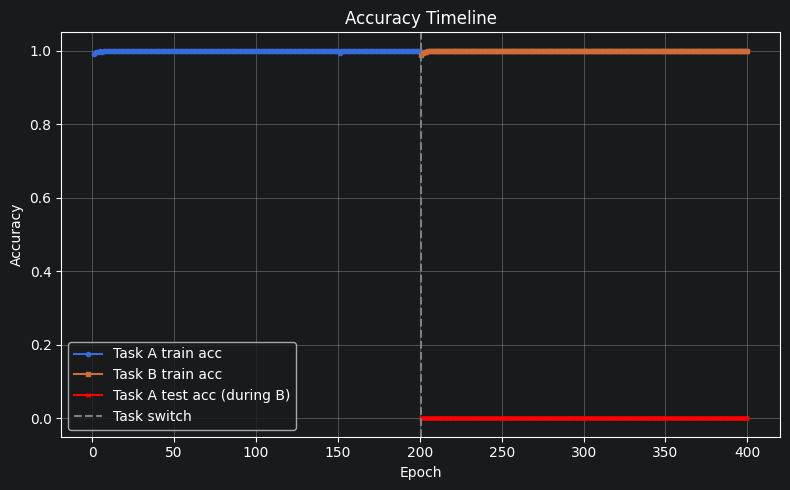

In [10]:
plot_accuracy_timeline(accA, accB, EPOCHS_A, EPOCHS_B, acc_a_during_b=accA_during_B)
plt.show()

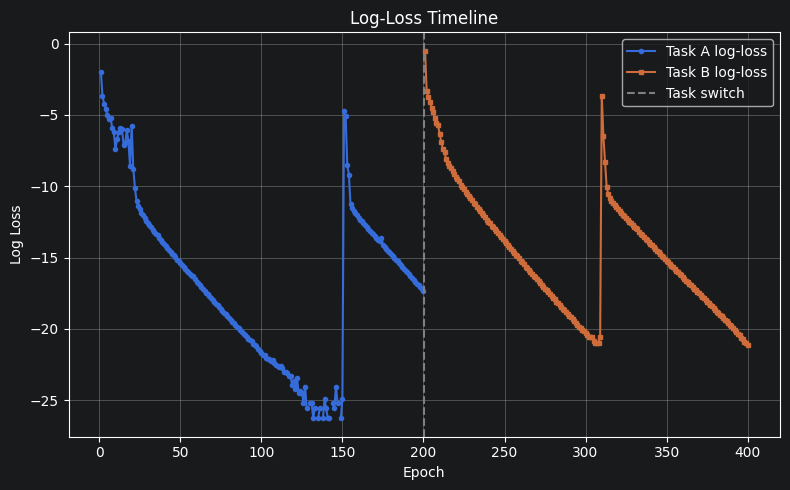

In [13]:
plot_loss_timeline(lossA, lossB, EPOCHS_A, EPOCHS_B)
plt.show()

## 8. Training trajectory on Task A's landscape

The white dashed line shows how the weights **moved away** from Task A's
minimum as the model was optimised for Task B. This is the geometric picture
of catastrophic forgetting - the new gradient steps push the parameters out
of the region that works well for the old task.

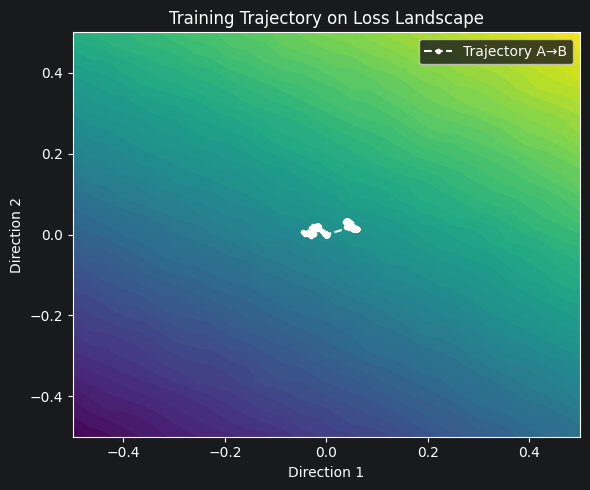

In [12]:
plot_trajectory_overlay(snapshots, landscape_A)
plt.show()

## Summary

| Metric                        | Value          |
|-------------------------------|----------------|
| Task A accuracy before Task B | 0.998          |
| Task A accuracy after Task B  | 0.000          |
| Task B final accuracy         | 0.994          |